<a href="https://colab.research.google.com/github/RonGopal/intro_to_AI/blob/main/FinalProjectPt04rrg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [88]:
mnist = fetch_openml(
 "mnist_784",
 version=1,
 as_frame=False
)
X = mnist.data
y = mnist.target

In [89]:
print('Shape: ', X.shape)
print('Data Types: ', X.dtype)
print('Min pixel value: ', X.min())
print('Max pixel value: ', X.max())

Shape:  (70000, 784)
Data Types:  int64
Min pixel value:  0
Max pixel value:  255


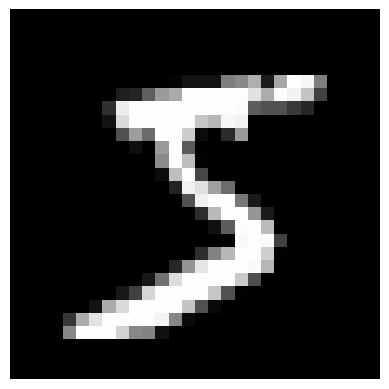

In [90]:
plt.imshow(
 X[0].reshape(28, 28),
 cmap="gray"
)
plt.axis("off")
plt.show()

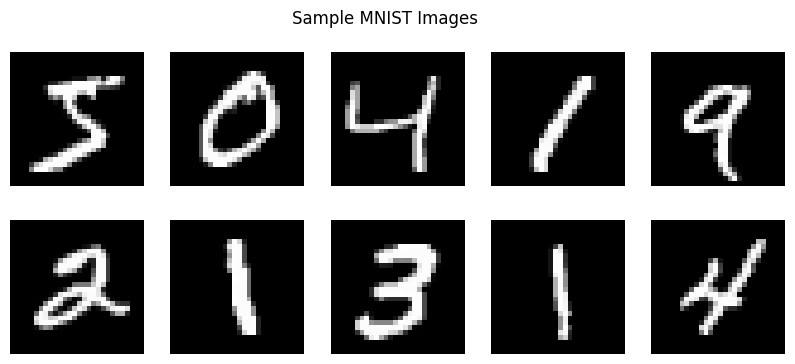

In [91]:
# Display sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("Sample MNIST Images")
plt.show()

In [92]:
X = X / 255.0

In [93]:
rng = np.random.RandomState(42)
sample_indices = rng.choice(
 len(X),
 size=10000,
 replace=False
)
X_sample = X[sample_indices]
y_sample = y[sample_indices]

In [94]:
k_values = [5, 10, 15]
inertia = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_sample)
    inertia.append(kmeans.inertia_)
    print(f"K = {k}, Inertia = {kmeans.inertia_}")

K = 5, Inertia = 432527.7509384551
K = 10, Inertia = 390343.0628082017
K = 15, Inertia = 365525.2325064674


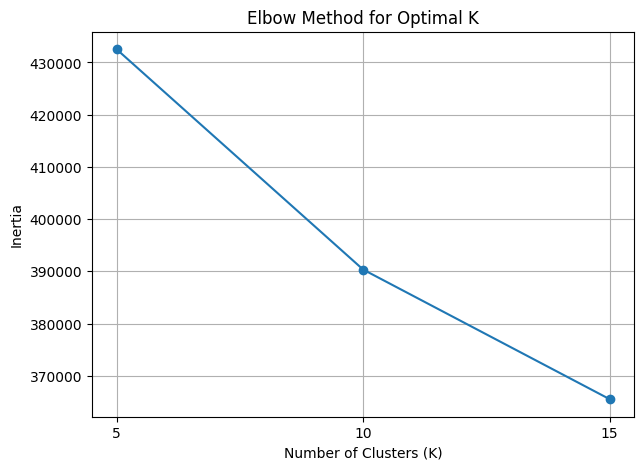

In [95]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [96]:
kmeans = KMeans(
 n_clusters=10,
 random_state=42,
 n_init=10
)

clusters = kmeans.fit_predict(X_sample)

print('Cluster Assignments: ', clusters[:20])

Cluster Assignments:  [3 2 5 2 2 0 9 4 7 4 8 4 4 3 1 3 2 7 2 5]


In [97]:
cluster_counts = pd.Series(clusters).value_counts().sort_index()
print("Cluster Sizes:")
print(cluster_counts)

Cluster Sizes:
0     519
1     757
2    1487
3    1039
4    1475
5    1331
6     513
7     906
8    1017
9     956
Name: count, dtype: int64


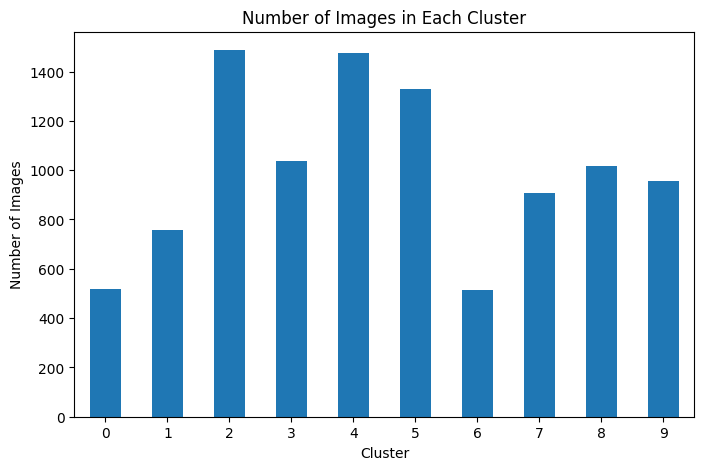

In [98]:
cluster_counts.plot(kind='bar', figsize=(8, 5))
plt.xlabel('Cluster')
plt.ylabel('Number of Images')
plt.title('Number of Images in Each Cluster')
plt.xticks(rotation=0)
plt.show()

In [99]:
centroids = kmeans.cluster_centers_

print('Centroid shape: ', centroids.shape)

Centroid shape:  (10, 784)


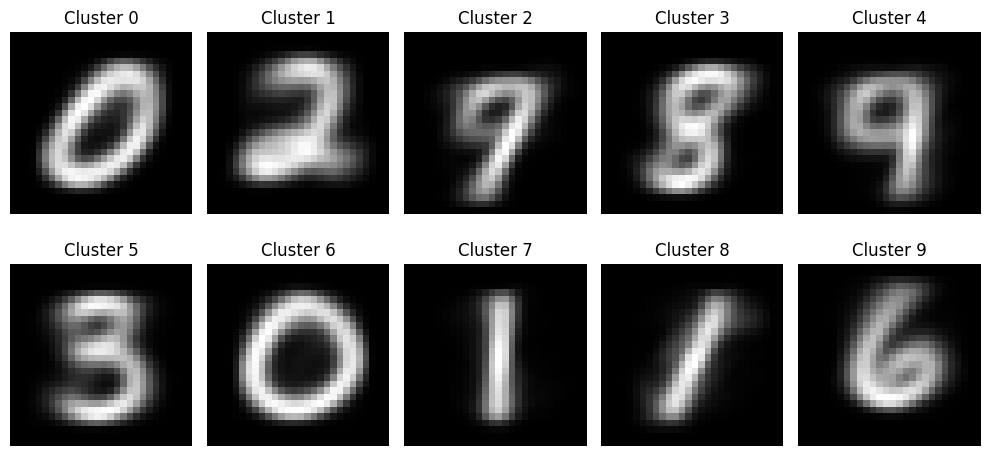

In [100]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
 ax.imshow(
  centroids[i].reshape(28, 28),
  cmap="gray"
 )
 ax.set_title(f"Cluster {i}")
 ax.axis("off")

plt.tight_layout()
plt.show()

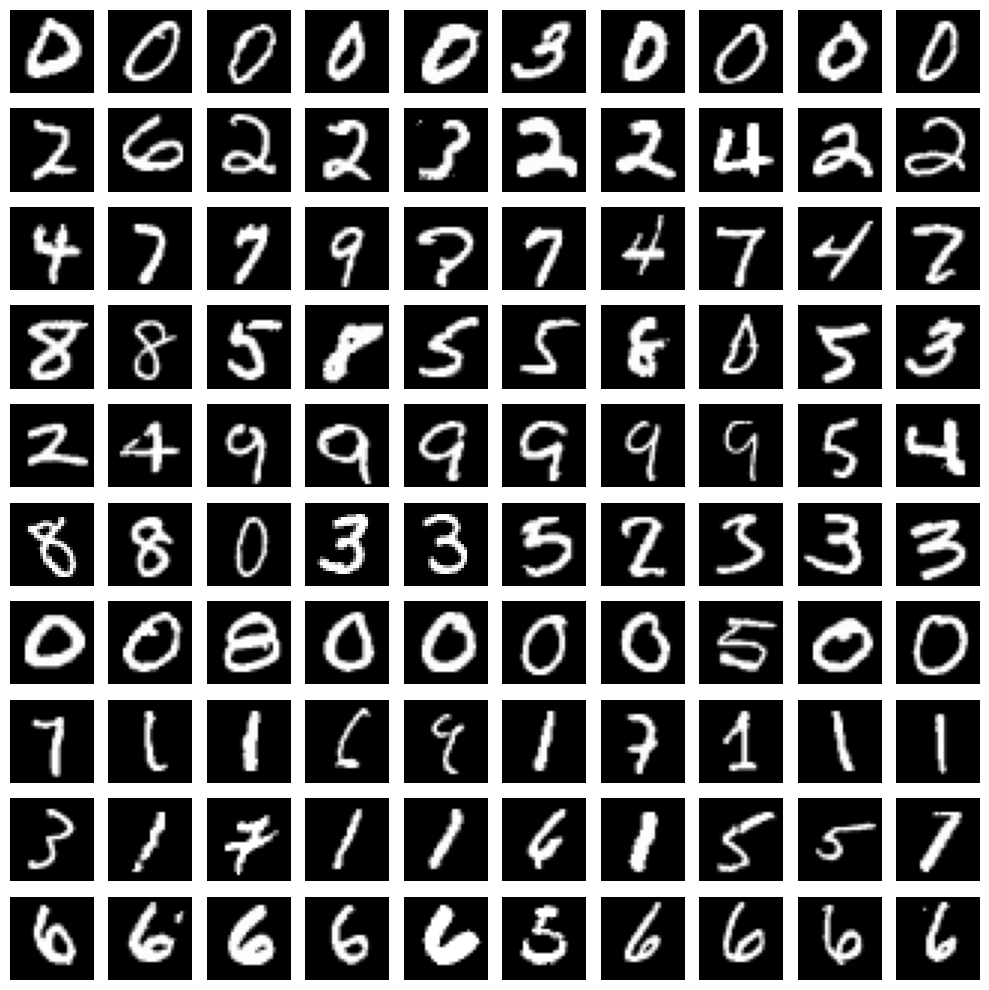

In [101]:
fig, axes = plt.subplots(10, 10, figsize=(10, 10))

for cluster_id in range(10):
  cluster_indices = np.where(clusters == cluster_id)[0]
  selected_indices = cluster_indices[:10]

  for j in range(10):
    ax = axes[cluster_id, j]
    if j < len(selected_indices):
      image_index = selected_indices[j]
      ax.imshow(
        X_sample[image_index].reshape(28, 28),
        cmap="gray"
      )
    ax.axis('off')

  axes[cluster_id, 0].set_ylabel(
      f'C{cluster_id}',
      rotation=0,
      labelpad=15
  )

plt.tight_layout()
plt.show()

In [102]:
cluster_digit_table = pd.crosstab(
 clusters,
 y_sample
)

cluster_digit_table

col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,427,0,11,17,0,39,14,1,7,3
1,5,1,666,42,8,4,10,9,12,0
2,4,1,8,7,290,57,1,654,23,442
3,22,2,20,146,4,266,9,1,560,9
4,3,4,26,33,500,63,14,295,34,503
5,31,5,71,700,0,310,4,0,197,13
6,458,0,5,2,2,5,26,2,6,7
7,0,642,45,55,16,18,34,34,32,30
8,2,497,70,24,49,155,48,57,87,28


In [103]:
most_common_digit = cluster_digit_table.idxmax(axis=1)

print('Most Common Digit in Each Cluster: ')
most_common_digit

Most Common Digit in Each Cluster: 


,0
row_0,
0,0
1,2
2,7
3,8
4,9
5,3
6,0
7,1
8,1


In [104]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

print('PCA Shape: ', X_pca.shape)

PCA Shape:  (10000, 2)


/tmp/ipykernel_4636/2318200037.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


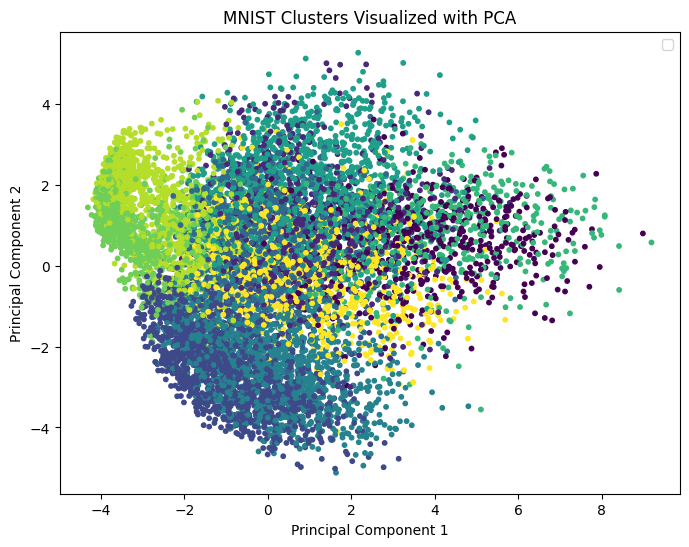

In [110]:
plt.figure(figsize=(8, 6))
plt.scatter(
 X_pca[:, 0],
 X_pca[:, 1],
 c=clusters,
 s=10
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST Clusters Visualized with PCA")
plt.show()

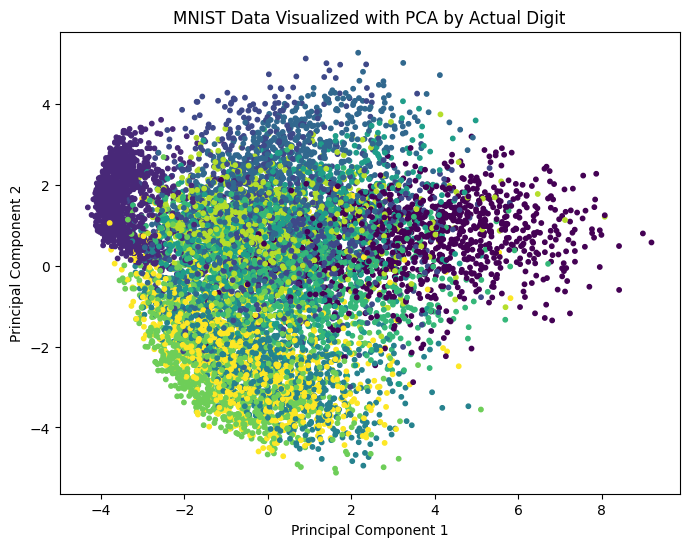

In [106]:
plt.figure(figsize=(8, 6))
plt.scatter(
 X_pca[:, 0],
 X_pca[:, 1],
 c=y_sample.astype(int),
 s=10
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST Data Visualized with PCA by Actual Digit")
plt.show()

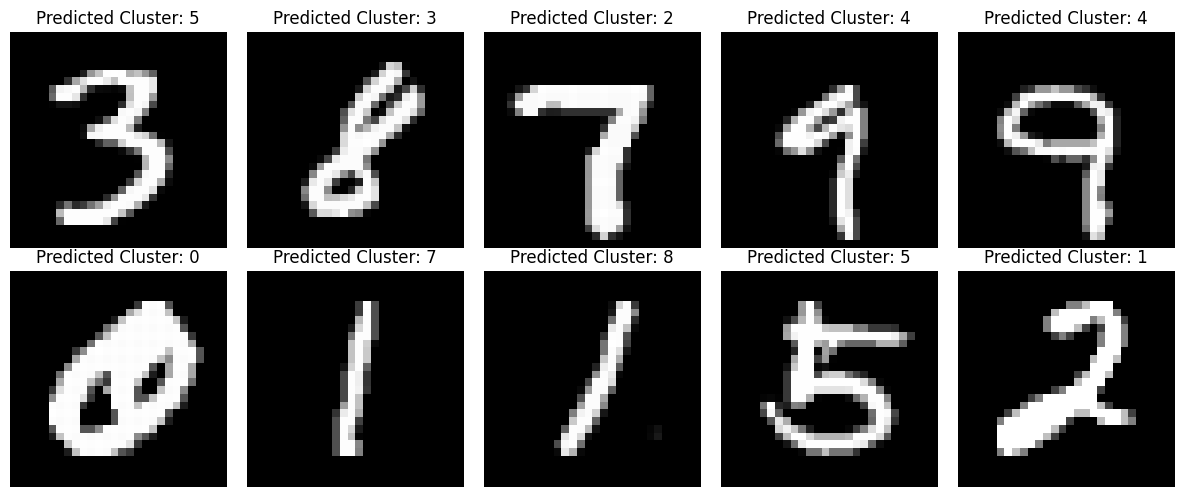

In [107]:
X_new = X[10000:10010]
y_new = y[10000:10010]
#Predict their clusters:
new_clusters = kmeans.predict(X_new)

# Display the images and their predicted cluster numbers
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_new[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Predicted Cluster: {new_clusters[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()